In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)

tau = 20
names = ["Fp1", "F3", "O1"]
C = len(names)

# Ders 12'deki gibi: Fp1 -> F3 nedensellik ilişkili, O1 bağımsız
ch1 = np.random.randn(tau)
ch2 = 0.7*np.roll(ch1, 2) + 0.3*np.random.randn(tau)   # basit gecikmeli ilişki (segment kısa olduğu için basitleştirilmiş)
ch3 = np.random.randn(tau)

X0 = torch.tensor(np.stack([ch1, ch2, ch3]), dtype=torch.float32)   # (C, tau) -- node feature = ham segment
A = torch.tensor([
    [0.0, 0.0, 0.0],
    [0.9, 0.0, 0.0],   # F3, Fp1'den geliyor (A[F3,Fp1]=0.9 -> "F3'ün komşusu Fp1")
    [0.0, 0.0, 0.0],
])
print("Node feature shape (C, tau):", X0.shape)

Node feature shape (C, tau): torch.Size([3, 20])


In [ ]:
def attention_scores(X, A, w_alpha):
    C = X.shape[0]
    Z = torch.full((C,C), float('-inf'))
    for v in range(C):
        for u in range(C):
            if A[v,u] > 0:
                concat = torch.cat([X[v], X[u]])
                Z[v,u] = F.leaky_relu(torch.dot(w_alpha, concat))
    return Z

def neighbor_aggregation(X, alpha, A):
    C = X.shape[0]
    H_new = torch.zeros_like(X)
    for v in range(C):
        neighbors = [u for u in range(C) if A[v,u] > 0]
        if neighbors:
            H_new[v] = sum(alpha[v,u]*X[u] for u in neighbors)
    return H_new

def gat_layer_with_residual(X, A, w_alpha):
    Z = attention_scores(X, A, w_alpha)
    alpha = torch.nan_to_num(F.softmax(Z, dim=1))
    agg = neighbor_aggregation(X, alpha, A)
    return torch.tanh(X + agg)   # Eş. 27: kendi değeri (residual) + komşu agregasyonu

d = tau
w1 = torch.randn(2*d) * 0.1
w2 = torch.randn(2*d) * 0.1

H1 = gat_layer_with_residual(X0, A, w1)   # Katman 1
H2 = gat_layer_with_residual(H1, A, w2)   # Katman 2 (L=2)
print("Katman 2 sonrası shape:", H2.shape)

Katman 2 sonrası shape: torch.Size([3, 20])


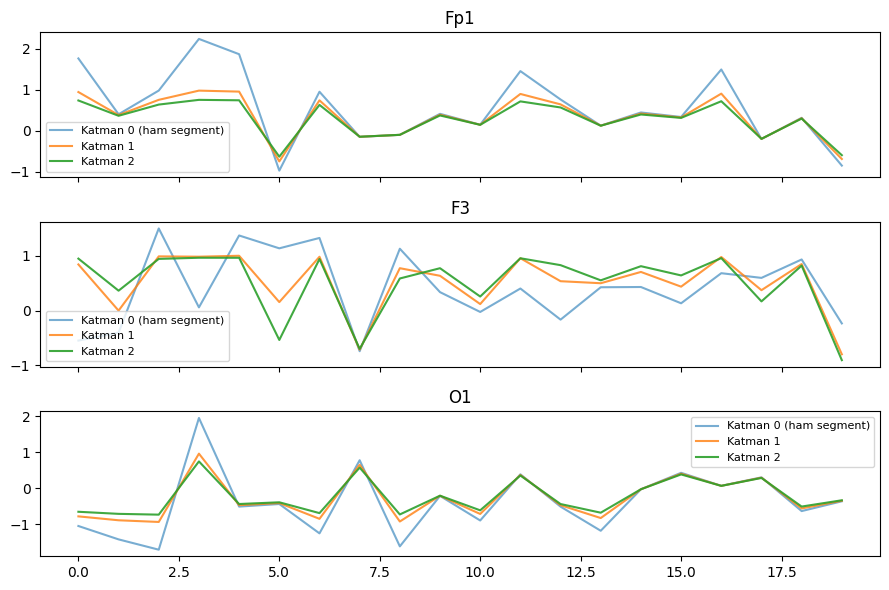

In [ ]:
fig, axes = plt.subplots(3,1, figsize=(9,6), sharex=True)
for i, name in enumerate(names):
    axes[i].plot(X0[i].numpy(), label='Katman 0 (ham segment)', alpha=0.6)
    axes[i].plot(H1[i].detach().numpy(), label='Katman 1', alpha=0.8)
    axes[i].plot(H2[i].detach().numpy(), label='Katman 2', alpha=0.9)
    axes[i].set_title(name)
    axes[i].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
h_segment = H2.mean(dim=0)   # (tau,) -- Eş. 28
print("Tek segment için local feature (h) shape:", h_segment.shape)

Tek segment için local feature (h) shape: torch.Size([20])


In [ ]:
def process_one_segment(seed):
    torch.manual_seed(seed); np.random.seed(seed)
    c1 = np.random.randn(tau)
    c2 = 0.7*np.roll(c1,2) + 0.3*np.random.randn(tau)
    c3 = np.random.randn(tau)
    X = torch.tensor(np.stack([c1,c2,c3]), dtype=torch.float32)
    h1 = gat_layer_with_residual(X, A, w1)
    h2 = gat_layer_with_residual(h1, A, w2)
    return h2.mean(dim=0)

K_prime = 2   # 2 mod
N_tau_example = 3   # her mod için 3 pencere

all_h = []
seed_counter = 0
for k in range(K_prime):
    for i in range(N_tau_example):
        all_h.append(process_one_segment(seed_counter))
        seed_counter += 1

H_tau = torch.cat(all_h)   # Eş. 30: hepsini uç uca ekle
print(f"Toplam ({K_prime} mod x {N_tau_example} pencere) segmentten H_τ shape:", H_tau.shape)

Toplam (2 mod x 3 pencere) segmentten H_τ shape: torch.Size([120])
